<h1 style="font-size:2rem;color:green;">Breast Cancer Classification Using Machine Learning</h1>

#### Import Libraries

In [1]:
import warnings
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBClassifier

# Reduce warning noise
warnings.filterwarnings("ignore", category=DeprecationWarning)
tf.get_logger().setLevel(logging.ERROR)

# Improve reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 1.0 Step 1: Problem Definition and Methodology

### 1.1 Problem Definition

Breast cancer classification is an important healthcare machine learning task because screening-derived features can help distinguish **benign** and **malignant** cases. However, classification can be challenging because tumor characteristics vary across observations and features may interact in complex ways.

This project aims to develop and evaluate machine learning models that classify breast cancer cases as **benign** or **malignant** using features derived from digitized screening records. The objective is to compare algorithms that support a healthcare ML decision-support workflow, especially models that maintain strong recall for malignant cases while preserving high overall accuracy.

By comparing supervised learning models, optimizing selected models through cross-validation and hyperparameter tuning, and analyzing generalization behavior, this project provides a responsible portfolio-scale classification experiment using screening-derived features.

### 1.2 Methodology

This project followed a systematic machine learning pipeline for binary classification of breast cancer cases as malignant or benign. The dataset was first loaded and cleaned by removing unnecessary identifiers and mapping categorical diagnosis labels to numerical values. Exploratory data analysis was performed to understand class distribution, feature characteristics, and potential correlations.

After feature-target separation, the data was split into an 80% training set and a 20% test set. `StandardScaler` was fit only on the training features, then the fitted scaler was used to transform both the training and test features. Five supervised models were then applied: Logistic Regression, Decision Tree, Random Forest, XGBoost, and a Neural Network. Cross-validation (5-fold) was used to estimate generalization performance and support bias-variance analysis.

For model tuning, hyperparameter optimization was conducted for Decision Tree, Random Forest, and XGBoost using GridSearchCV. The Neural Network was built with TensorFlow/Keras, using dropout layers, ReLU activations, early stopping, and binary crossentropy loss.

Model performance was measured using accuracy, precision, recall, F1-score, and confusion matrices. Learning curves and cross-validation scores were generated to evaluate model behavior with increasing data and to assess overfitting or underfitting. Additionally, K-Means clustering and Isolation Forest were used for exploratory pattern discovery and anomaly review.

## 2.0 Step 2: Data Preprocessing and Exploratory Data Analysis

### 2.1 Data Loading and Initial Inspection

In [2]:
df = pd.read_csv('../data/BreastCancer_Screening.csv')
print("Shape of the dataset:", df.shape)
print("\nFirst 5 rows:\n", df.head())

Shape of the dataset: (569, 32)

First 5 rows:
          ID Diagnosis  Radius1  Texture1  Perimeter1   Area1  Smoothness1  \
0    842302         M    17.99     10.38      122.80  1001.0      0.11840   
1    842517         M    20.57     17.77      132.90  1326.0      0.08474   
2  84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3  84348301         M    11.42     20.38       77.58   386.1      0.14250   
4  84358402         M    20.29     14.34      135.10  1297.0      0.10030   

   Compactness1  Concavity1  Concave_Points1  ...  Radius3  Texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   Perimeter3   Area3  Smoothness3  Compactness3  Concav

### 2.2 Data Cleaning and Overview

In [3]:
# Check for missing values
missing_counts = df.isnull().sum()
print("\nMissing values per column:\n", missing_counts[missing_counts > 0])

# Check for duplicated rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

# Data Types
print("\nData types:\n", df.dtypes)


Missing values per column:
 Series([], dtype: int64)

Number of duplicate rows: 0

Data types:
 ID                      int64
Diagnosis              object
Radius1               float64
Texture1              float64
Perimeter1            float64
Area1                 float64
Smoothness1           float64
Compactness1          float64
Concavity1            float64
Concave_Points1       float64
Symmetry1             float64
Fractal_Dimension1    float64
Radius2               float64
Texture2              float64
Perimeter2            float64
Area2                 float64
Smoothness2           float64
Compactness2          float64
Concavity2            float64
Concave_Points2       float64
Symmetry2             float64
Fractal_Dimension2    float64
Radius3               float64
Texture3              float64
Perimeter3            float64
Area3                 float64
Smoothness3           float64
Compactness3          float64
Concavity3            float64
Concave_Points3       float64
Sym

### 2.3 Exploratory Analysis

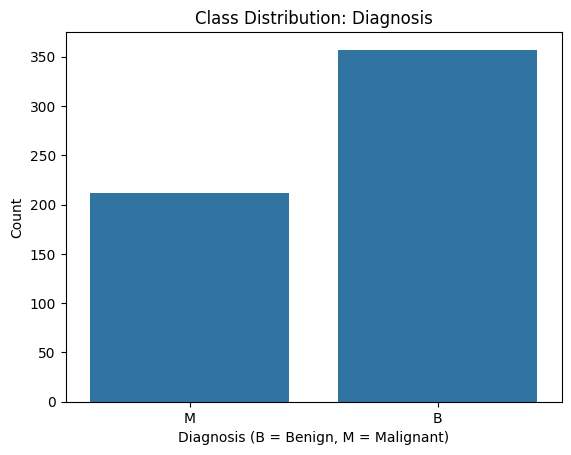

In [4]:
# Class Distribution
sns.countplot(x='Diagnosis', data=df)
plt.title('Class Distribution: Diagnosis')
plt.xlabel('Diagnosis (B = Benign, M = Malignant)')
plt.ylabel('Count')
plt.show()

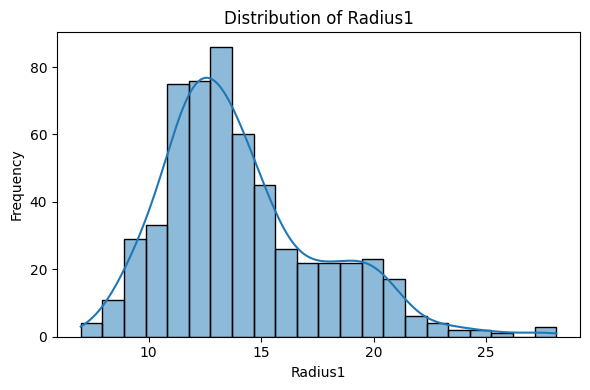

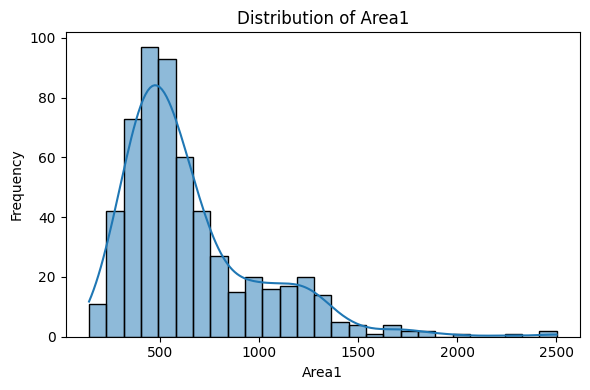

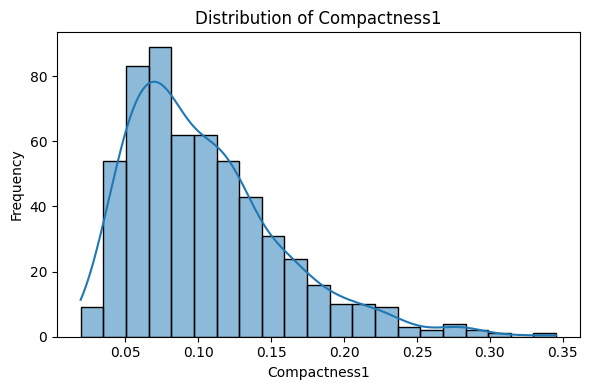

In [5]:
# Visualize Distribution of a few important features
features_to_plot = ['Radius1', 'Area1', 'Compactness1']

for feature in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

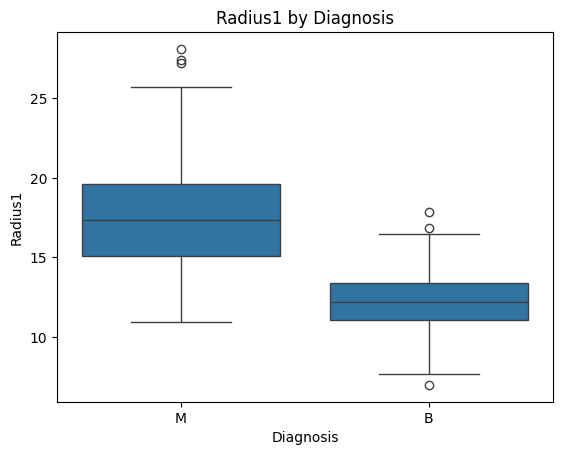

In [6]:
# Use Box Plot to Compare feature distribution by diagnosis
sns.boxplot(x='Diagnosis', y='Radius1', data=df)
plt.title('Radius1 by Diagnosis')
plt.show()

### 2.4 Data Preprocessing and Feature Engineering

In [7]:
# Drop the ID column, its just an identifier and not predictive
df = df.drop(columns=['ID'])

# We need to convert the Diagnosis column to numerical from categorical
# M=1, B=0
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# Separate features and target
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']
df['Diagnosis'].value_counts()

Diagnosis
0    357
1    212
Name: count, dtype: int64

### 2.5 Feature Scaling

In [8]:
# Split the data before scaling to avoid preprocessing leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fit the scaler only on the training features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Keep a full transformed feature matrix for exploratory downstream cells if needed.
# The scaler is still fit only on X_train_raw.
X_scaled = scaler.transform(X)

# Check shapes
print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

Training feature shape: (455, 30)
Test feature shape: (114, 30)


## 3.0 Step 3: Supervised Learning Implementation (Logistic Regression and Decision Tree)

### 3.1 logistic Regression Classifier

In [9]:
# Convert the corrected train-test split to numpy arrays for manual logistic regression
# Add a bias/intercept column after scaling
X_train_np = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test_np = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

y_train_np = y_train.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

#### 3.1a Implement Sigmoid Function

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Testing the function
test_values = np.array([-10, -1, 0, 1, 10])
sigmoid_outputs = sigmoid(test_values)

print("Input values: ", test_values)
print("Sigmoid output: ", np.round(sigmoid_outputs, 4))

Input values:  [-10  -1   0   1  10]
Sigmoid output:  [0.     0.2689 0.5    0.7311 1.    ]


#### 3.1b Implementation of the Cost and Gradient function (With L2 Regularization)

In [11]:
def compute_cost(x, y, weights, lambda_reg=0.1):
    #print("x shape:", x.shape)
    #print("weights shape:", weights.shape)
    m = len(y)
    h = sigmoid(x @ weights)
    reg = (lambda_reg / (2 * m)) * np.sum(np.square(weights[1:]))
    cost = (-1 / m) * np.sum(y * np.log(h + 1e-10) + (1 - y) * np.log(1 - h + 1e-10)) + reg
    return cost

def compute_gradient(x, y, weights, lambda_reg=0.1):
    m = len(y)
    h = sigmoid(x @ weights)
    error = h - y
    grad = (1 / m) * (x.T @ error)
    grad[1:] += (lambda_reg / m) * weights[1:]
    return grad

#### 3.1c Gradient Descent Implementation

In [12]:
def gradient_descent(x, y, lr=0.1, iterations=1000, lambda_reg=0.1):
    weights = np.zeros((x.shape[1], 1))
    cost_history = []
    for i in range(iterations):
        cost = compute_cost(x, y, weights, lambda_reg)
        grad = compute_gradient(x, y, weights, lambda_reg)
        weights -= lr * grad
        cost_history.append(cost)

    return weights, cost_history

#### 3.1d Model Training, Prediction and Evaluation

In [13]:
# Train model
weights_final, cost_history = gradient_descent(X_train_np, y_train_np, lr=0.1, iterations=1000, lambda_reg=0.1)

def predict(x, weights, threshold=0.5):
    return (sigmoid(x @ weights) >= threshold).astype(int)

# Predict on test set
y_pred_manual = predict(X_test_np, weights_final)

# Evaluate
print("Accuracy:", accuracy_score(y_test_np, y_pred_manual))
print("Confusion Matrix:\n", confusion_matrix(y_test_np, y_pred_manual))
print("\nClassification Report:\n", classification_report(y_test_np, y_pred_manual))

Accuracy: 0.9824561403508771
Confusion Matrix:
 [[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### 3.1e Cost convergence Plot

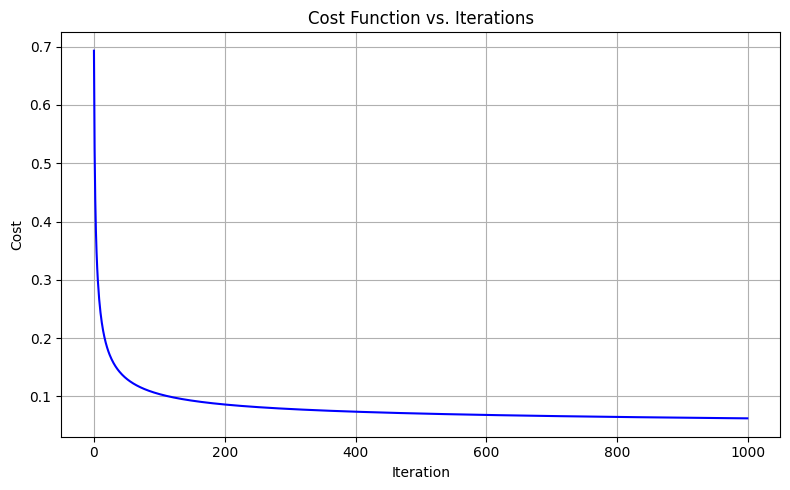

In [14]:
# Cost vs Iteration
plt.figure(figsize=(8, 5))
plt.plot(range(len(cost_history)), cost_history, color='blue')
plt.title("Cost Function vs. Iterations")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 3.1f Confusion Matrix for Logistic Regression

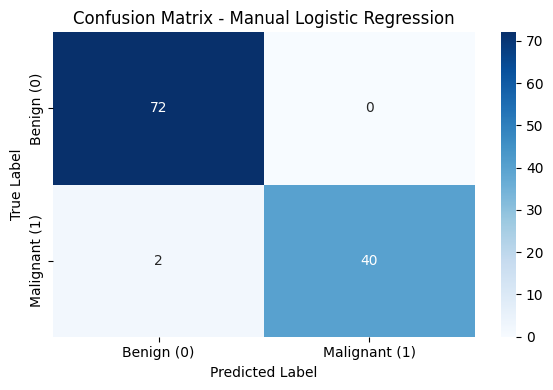

In [15]:
cm = confusion_matrix(y_test_np, y_pred_manual)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Confusion Matrix - Manual Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 3.2 Train and Evaluate a Decision Tree

#### 3.2a Optimize the Decision Tree

In [16]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize base model
dt_base = DecisionTreeClassifier(random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt_base, param_grid=param_grid, 
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=0)

# Fit to training data
grid_search.fit(X_train, y_train)

# Get best model
best_dt_model = grid_search.best_estimator_

# Predict and evaluate on test set
y_pred_best_dt = best_dt_model.predict(X_test)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_best_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_dt))

Tuned Decision Tree Accuracy: 0.956140350877193

Confusion Matrix:
 [[72  0]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



#### 3.2b Visualize the Confusion Matrix for Decision Tree

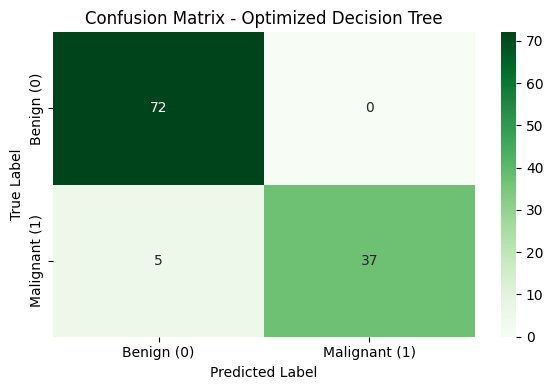

In [17]:
cm_dt = confusion_matrix(y_test, y_pred_best_dt)


plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Optimized Decision Tree')
plt.tight_layout()
plt.show()

### 3.3 Comparison of Performance for the two Models (Decision Tree & Logistic regression)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Flatten y_test if not already flattened
y_test_flat = y_test_np.ravel()

# Compare only Logistic Regression and Decision Tree
models_summary = {
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test_flat, y_pred_manual),
        accuracy_score(y_test_flat, y_pred_best_dt)
    ],
    "Precision (Class 1)": [
        precision_score(y_test_flat, y_pred_manual),
        precision_score(y_test_flat, y_pred_best_dt)
    ],
    "Recall (Class 1)": [
        recall_score(y_test_flat, y_pred_manual),
        recall_score(y_test_flat, y_pred_best_dt)
    ],
    "F1 Score (Class 1)": [
        f1_score(y_test_flat, y_pred_manual),
        f1_score(y_test_flat, y_pred_best_dt)
    ]
}

comparison_df = pd.DataFrame(models_summary)
comparison_df



,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1 Score (Class 1)
0,Logistic Regression,0.982456,1.0,0.952381,0.975610
1,Decision Tree,0.956140,1.0,0.880952,0.936709


## 4.0 Step 4: Neural Network Implementation

### 4.1 Data Preparation

In [19]:
from sklearn.utils import class_weight

# Use the corrected scaled train-test split; no bias term is needed in Keras
X_train_nn = X_train
X_test_nn = X_test
y_train_nn = y_train.values.ravel()
y_test_nn = y_test.values.ravel()

# Compute class weights (optional but useful for imbalanced classes)
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nn),
    y=y_train_nn
)
class_weights = dict(enumerate(cw))

### 4.2 Neural Network Architecture

In [20]:
from tensorflow.keras.optimizers import Adam
# Build the model
model = Sequential([
    Dense(64, input_shape=(X_train_nn.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # For binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

c:\Users\Edidionn Ibokete\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 4.3 Training and Evaluation

In [21]:

# Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_nn, y_train_nn, 
    epochs=35,
    batch_size=16,
    validation_split=0.1, 
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

### 4.4 Learning Curves

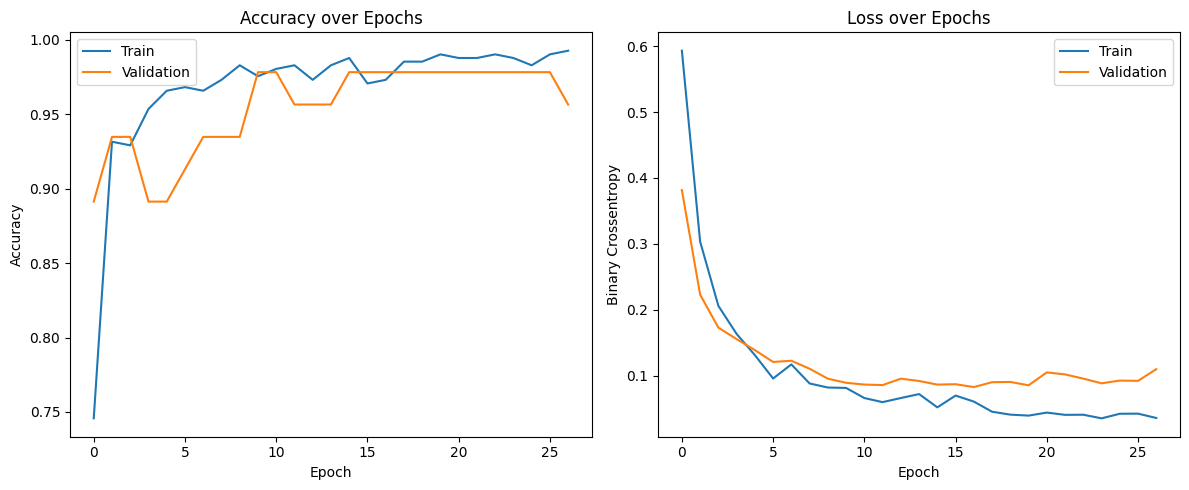

In [22]:
# Plot the curves
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

plt.tight_layout()
plt.show()


### 4.5 Evaluate Model Performance

In [23]:
# Predict probabilities
y_pred_prob_nn = model.predict(X_test_nn)

# Convert probabilities to binary class predictions (0 or 1)
y_pred_nn = (y_pred_prob_nn >= 0.5).astype(int)

# Evaluate
print("Neural Network Accuracy:", accuracy_score(y_test_nn, y_pred_nn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_nn, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_nn, y_pred_nn))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Neural Network Accuracy: 0.9824561403508771

Confusion Matrix:
 [[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 5.0 Step 5: Unsupervised Learning and Anomaly Detection

### 5.1 K-Means Clustering on Subset of Dataset

In [24]:
# Select subset of features
# These selected features relate to cell size/structure
subset_features = ['Radius1', 'Texture1', 'Area1', 'Perimeter1']
X_cluster = df[subset_features].copy()

# Normalize
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)


#### 5.1a Implementation of K-means Functions

In [25]:
# Find closest centroid
def find_closest_centroids(X, centroids):
    idx = np.zeros(X.shape[0], dtype=int)
    for i in range(X.shape[0]):
        distances = np.linalg.norm(X[i] - centroids, axis=1)
        idx[i] = np.argmin(distances)
    return idx

# Compute new centroids
def compute_centroids(X, idx, K):
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        points = X[idx == k]
        if len(points) > 0:
            centroids[k] = np.mean(points, axis=0)
    return centroids

# Initialize centroids
def initialize_centroids(X, K):
    return X[np.random.choice(X.shape[0], K, replace=False)]

# Full K-means loop
def run_kmeans(X, initial_centroids, max_iters=100):
    centroids = initial_centroids
    for _ in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        new_centroids = compute_centroids(X, idx, centroids.shape[0])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return centroids, idx

# Parameters
K = 2  # Number of clusters
max_iters = 100

# Initialize and run
initial_centroids = initialize_centroids(X_cluster_scaled, K)
centroids, idx = run_kmeans(X_cluster_scaled, initial_centroids, max_iters)


#### 5.1b Visualize Clusters

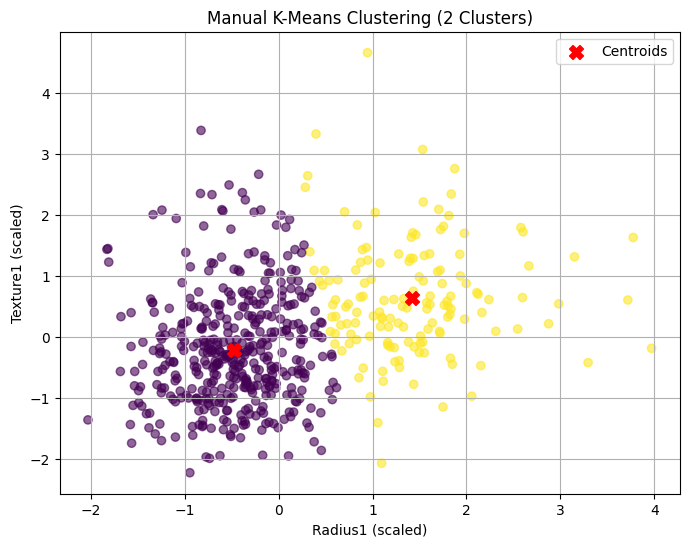

Silhouette Score: 0.528


In [26]:
# Plotting Cluster Assignments
plt.figure(figsize=(8, 6))
plt.scatter(X_cluster_scaled[:, 0], X_cluster_scaled[:, 1], c=idx, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=100, label='Centroids')
plt.title('Manual K-Means Clustering (2 Clusters)')
plt.xlabel('Radius1 (scaled)')
plt.ylabel('Texture1 (scaled)')
plt.legend()
plt.grid(True)
plt.show()

score = silhouette_score(X_cluster_scaled, idx)
print(f"Silhouette Score: {score:.3f}")


### 5.2 Isolation Forest for Anomaly Detection

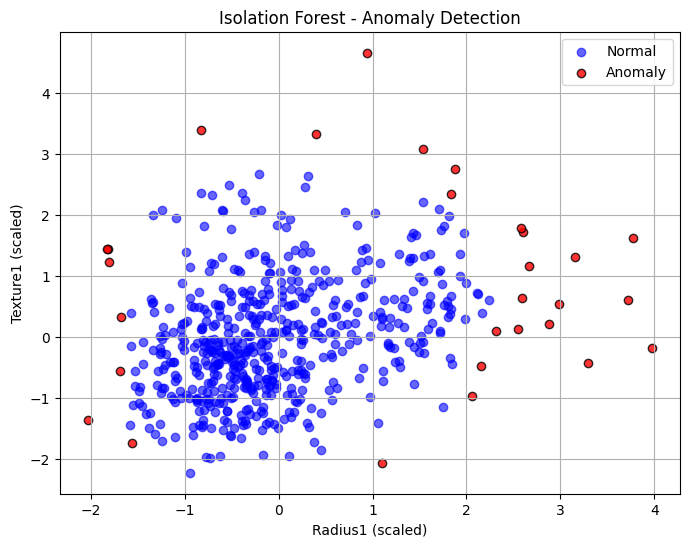

Number of anomalies detected: 29
Number of normal points: 540


In [27]:
from sklearn.ensemble import IsolationForest

#  Fit Isolation Forest ---
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_cluster_scaled)  # -1 = anomaly, 1 = normal

#  Visualize Anomalies ---
normal = anomaly_labels == 1
anomaly = anomaly_labels == -1

plt.figure(figsize=(8, 6))
plt.scatter(X_cluster_scaled[normal, 0], X_cluster_scaled[normal, 1],
            c='blue', label='Normal', alpha=0.6)
plt.scatter(X_cluster_scaled[anomaly, 0], X_cluster_scaled[anomaly, 1],
            c='red', label='Anomaly', alpha=0.8, edgecolors='k')
plt.title("Isolation Forest - Anomaly Detection")
plt.xlabel("Radius1 (scaled)")
plt.ylabel("Texture1 (scaled)")
plt.legend()
plt.grid(True)
plt.show()

# Anomaly Counts ---
n_anomalies = np.sum(anomaly)
n_normals = np.sum(normal)
print(f"Number of anomalies detected: {n_anomalies}")
print(f"Number of normal points: {n_normals}")

#### 5.2a Evaluation of Anomaly Results Against Actual Diagnosis Labels

Confusion Matrix (Diagnosis vs Detected Anomalies):
 [[349   8]
 [191  21]]


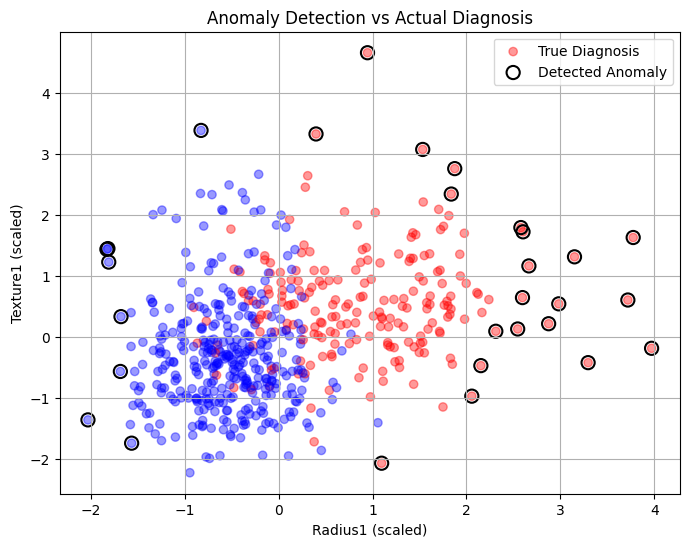

Accuracy Score: 0.6502636203866432

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.98      0.78       357
           1       0.72      0.10      0.17       212

    accuracy                           0.65       569
   macro avg       0.69      0.54      0.48       569
weighted avg       0.68      0.65      0.55       569



In [28]:
anomaly_binary = (anomaly_labels == -1).astype(int)
y_true = df['Diagnosis'].astype(int)

if len(anomaly_binary) == len(y_true):
    cm = confusion_matrix(y_true, anomaly_binary)
    print("Confusion Matrix (Diagnosis vs Detected Anomalies):\n", cm)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_cluster_scaled[:, 0], X_cluster_scaled[:, 1], c=y_true, cmap='bwr', alpha=0.4, label='True Diagnosis')
    plt.scatter(X_cluster_scaled[anomaly_binary == 1, 0], X_cluster_scaled[anomaly_binary == 1, 1],
                edgecolors='k', facecolors='none', s=90, linewidths=1.5, label='Detected Anomaly')
    plt.title("Anomaly Detection vs Actual Diagnosis")
    plt.xlabel("Radius1 (scaled)")
    plt.ylabel("Texture1 (scaled)")
    plt.legend()
    plt.grid(True)
    plt.show()

    y_pred = np.where(anomaly_labels == -1, 1, 0)
    print("Accuracy Score:", accuracy_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
else:
    print("Length mismatch: Cannot compare predictions to true labels.")


## 6.0 Step 6: Advanced Techniques and Ensemble Methods

### 6.1 Implement XGBoost methods

In [29]:
from xgboost import XGBClassifier

# Define parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Instantiate and run grid search
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=0
)

xgb_grid.fit(X_train, y_train)
best_xgb_model = xgb_grid.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Evaluate
xgb_tuned_results = {
    "Best Parameters": xgb_grid.best_params_,
    "Test Set Accuracy": accuracy_score(y_test, y_pred_xgb_tuned),
    "Confusion Matrix": confusion_matrix(y_test, y_pred_xgb_tuned),
    "Classification Report": classification_report(y_test, y_pred_xgb_tuned, output_dict=True)
}
# Print output
print("Best Parameters for XGBoost:")
print(xgb_tuned_results["Best Parameters"])

print("\nTest Set Accuracy:")
print(xgb_tuned_results["Test Set Accuracy"])

print("\nConfusion Matrix:")
print(xgb_tuned_results["Confusion Matrix"])

print("\nClassification Report:")
report_df = pd.DataFrame(xgb_tuned_results["Classification Report"]).transpose()
print(report_df.to_string())

Best Parameters for XGBoost:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

Test Set Accuracy:
0.9736842105263158

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score     support
0              0.960000  1.000000  0.979592   72.000000
1              1.000000  0.928571  0.962963   42.000000
accuracy       0.973684  0.973684  0.973684    0.973684
macro avg      0.980000  0.964286  0.971277  114.000000
weighted avg   0.974737  0.973684  0.973465  114.000000


### 6.2 Implement Random Forest 

In [30]:
from sklearn.ensemble import RandomForestClassifier

# Define and train the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9736842105263158

Confusion Matrix:
 [[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 7 Step 7: Model Evaluation and Comparison

### 7.1 Evaluate all Implemented Models

In [31]:
models_summary = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_manual),
        accuracy_score(y_test, y_pred_best_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb_tuned),
        accuracy_score(y_test_nn, y_pred_nn)
    ],
    "Precision (Class 1)": [
        precision_score(y_test, y_pred_manual),
        precision_score(y_test, y_pred_best_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb_tuned),
        precision_score(y_test_nn, y_pred_nn)
    ],
    "Recall (Class 1)": [
        recall_score(y_test, y_pred_manual),
        recall_score(y_test, y_pred_best_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb_tuned),
        recall_score(y_test_nn, y_pred_nn)
    ],
    "F1 Score (Class 1)": [
        f1_score(y_test, y_pred_manual),
        f1_score(y_test, y_pred_best_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb_tuned),
        f1_score(y_test_nn, y_pred_nn)
    ]
}

comparison_df = pd.DataFrame(models_summary)
display(comparison_df)


,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1 Score (Class 1)
0,Logistic Regression,0.982456,1.0,0.952381,0.975610
1,Decision Tree,0.956140,1.0,0.880952,0.936709
2,Random Forest,0.973684,1.0,0.928571,0.962963
3,XGBoost,0.973684,1.0,0.928571,0.962963
4,Neural Network,0.982456,1.0,0.952381,0.975610


### 7.2 Analyze bias - variance trade-off for each model

In [32]:
# Define models (using tuned parameters where applicable)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, subsample=1.0, eval_metric='logloss', random_state=42)
}

# Run cross-validation and compile dynamic bias-variance results
cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        return_train_score=True,
        scoring='accuracy'
    )

    train_score = scores['train_score'].mean()
    val_score = scores['test_score'].mean()
    gap = train_score - val_score

    cv_results.append({
        "Model": name,
        "Train Accuracy (mean)": train_score,
        "Validation Accuracy (mean)": val_score,
        "Gap (Train - Val)": gap
    })

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

                 Model  Train Accuracy (mean)  Validation Accuracy (mean)  \
0  Logistic Regression               0.986813                    0.971429   
1        Decision Tree               0.990110                    0.934066   
2        Random Forest               0.992857                    0.956044   
3              XGBoost               1.000000                    0.962637   

   Gap (Train - Val)  
0           0.015385  
1           0.056044  
2           0.036813  
3           0.037363  


### 7.3 Neural Network Bias-Variance Trade off

In [33]:
# Build model function
def build_nn():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Manual cross-validation for neural network
y_train_array = y_train.values.ravel() if hasattr(y_train, "values") else np.asarray(y_train).ravel()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_scores = []

for train_idx, val_idx in skf.split(X_train, y_train_array):
    tf.keras.backend.clear_session()

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train_array[train_idx], y_train_array[val_idx]

    fold_model = build_nn()
    fold_model.fit(
        X_fold_train,
        y_fold_train,
        epochs=50,
        batch_size=16,
        verbose=0
    )

    _, fold_accuracy = fold_model.evaluate(
        X_fold_val,
        y_fold_val,
        verbose=0
    )
    val_scores.append(fold_accuracy)

val_mean = np.mean(val_scores)

# Train final model on the full training set for training accuracy
tf.keras.backend.clear_session()
nn_model = build_nn()
nn_model.fit(
    X_train,
    y_train_array,
    epochs=50,
    batch_size=16,
    verbose=0
)

_, train_score = nn_model.evaluate(X_train, y_train_array, verbose=0)

# Store neural network results dynamically for later plotting
nn_results_df = pd.DataFrame([{
    "Model": "Neural Network",
    "Train Accuracy (mean)": train_score,
    "Validation Accuracy (mean)": val_mean,
    "Gap (Train - Val)": train_score - val_mean
}])

print("Neural Network Bias-Variance Analysis:")
print("Train Accuracy (mean):", round(train_score, 4))
print("Validation Accuracy (mean):", round(val_mean, 4))
print("Gap (Train - Val):", round(train_score - val_mean, 4))

Neural Network Bias-Variance Analysis:
Train Accuracy (mean): 1.0
Validation Accuracy (mean): 0.978
Gap (Train - Val): 0.022


### 7.4 Bias - Variance Plots

,Model,Train Accuracy (mean),Validation Accuracy (mean),Gap (Train - Val)
0,Logistic Regression,0.986813,0.971429,0.015385
1,Decision Tree,0.990110,0.934066,0.056044
2,Random Forest,0.992857,0.956044,0.036813
3,XGBoost,1.000000,0.962637,0.037363
4,Neural Network,1.000000,0.978022,0.021978


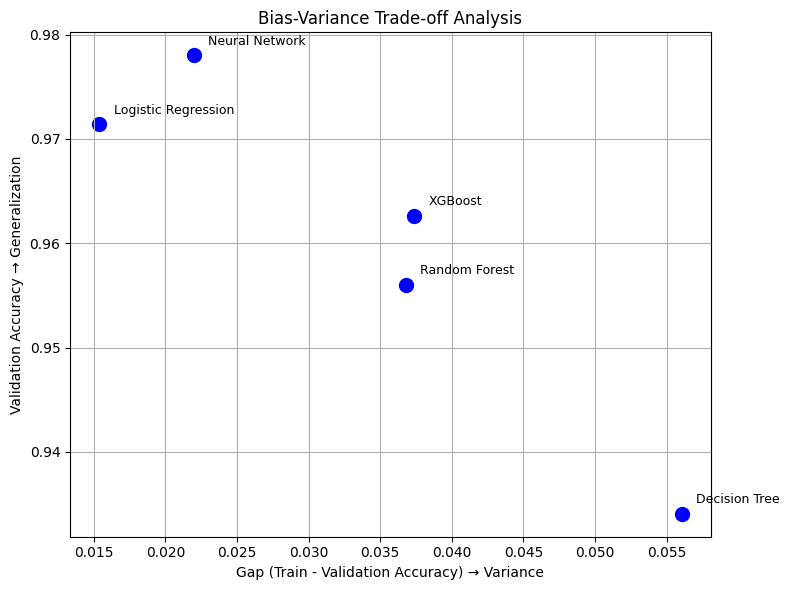

In [34]:
# Combine classical model results with neural network results dynamically
bias_variance_data = pd.concat(
    [cv_results_df, nn_results_df],
    ignore_index=True
)

# Display latest computed values
display(bias_variance_data)

# Create dynamic bias-variance scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(
    bias_variance_data["Gap (Train - Val)"],
    bias_variance_data["Validation Accuracy (mean)"],
    s=100,
    color="blue"
)

for _, row in bias_variance_data.iterrows():
    plt.text(
        row["Gap (Train - Val)"] + 0.001,
        row["Validation Accuracy (mean)"] + 0.001,
        row["Model"],
        fontsize=9
    )

plt.xlabel("Gap (Train - Validation Accuracy) → Variance")
plt.ylabel("Validation Accuracy → Generalization")
plt.title("Bias-Variance Trade-off Analysis")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 7.4a Bias-Variance Trade-off Analysis

Bias-variance analysis helps evaluate whether each model generalizes well or shows signs of underfitting or overfitting. In this section, 5-fold cross-validation was used to compare training accuracy, validation accuracy, and the train-validation gap for each implemented model. The gap is used as an estimate of variance: a larger gap suggests that the model fits the training data more strongly than the validation data.

The **Neural Network** achieved the highest validation accuracy at **0.9780**, with a training accuracy of **1.0000** and a moderate gap of **0.0220**. This suggests that the model has strong predictive capacity while still maintaining good validation performance. Although the perfect training accuracy shows that the model can fit the training data very closely, the relatively small validation gap indicates that dropout and the training setup helped control overfitting.

**Logistic Regression** also performed very strongly. It achieved a validation accuracy of **0.9714** with the smallest train-validation gap of **0.0154**. This makes it the most stable model in the bias-variance comparison. Even though Logistic Regression is a simpler linear model, its low variance and strong validation accuracy show that it generalizes well on this dataset.

**XGBoost** achieved a validation accuracy of **0.9626** with a gap of **0.0374**, while **Random Forest** achieved a validation accuracy of **0.9560** with a gap of **0.0368**. Both ensemble models showed high training accuracy and strong validation performance, but their larger gaps suggest moderate variance compared with Logistic Regression and the Neural Network. These results are expected because ensemble tree models are more flexible and can capture more complex feature interactions.

The **Decision Tree** had the weakest generalization performance. It achieved a training accuracy of **0.9901**, but its validation accuracy dropped to **0.9341**, producing the largest gap of **0.0560**. This indicates that the standalone tree is more prone to overfitting, even after limiting model complexity.

Overall, the Neural Network produced the highest validation accuracy, while Logistic Regression showed the most stable generalization behavior. Random Forest and XGBoost remained strong non-linear models but showed slightly higher variance. The Decision Tree was the least stable model and showed the clearest signs of overfitting.

### 7.5 Learning Curves for the Key Models

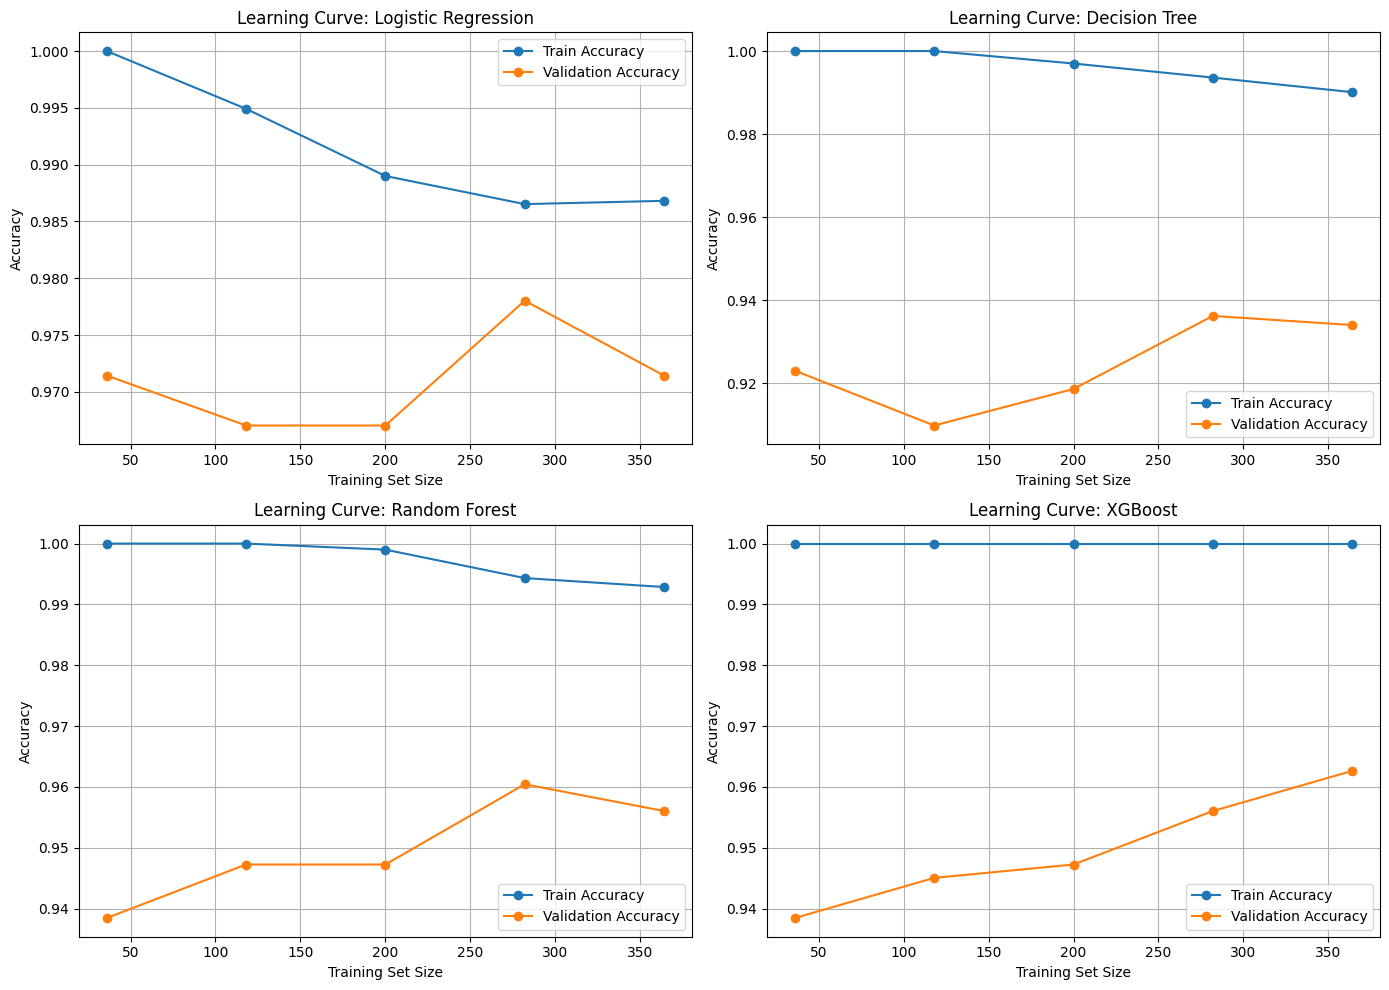

In [35]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Models to plot learning curves for
models_for_curves = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, subsample=1.0, eval_metric='logloss', random_state=42)
}

# Generate learning curves
train_sizes = np.linspace(0.1, 1.0, 5)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models_for_curves.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5, train_sizes=train_sizes, scoring='accuracy', n_jobs=-1
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)

    axes[i].plot(train_sizes_abs, train_scores_mean, label='Train Accuracy', marker='o')
    axes[i].plot(train_sizes_abs, val_scores_mean, label='Validation Accuracy', marker='o')
    axes[i].set_title(f"Learning Curve: {name}")
    axes[i].set_xlabel("Training Set Size")
    axes[i].set_ylabel("Accuracy")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

#### 7.5a Interpretation of the Learning Curves and Neural Network

The learning curves provide additional insight into how model performance changes as the training set size increases. They help show whether each model is limited by bias, variance, or data availability.

**Logistic Regression** showed stable behavior across the learning curve. Its training accuracy decreased slightly as more data was added, while validation accuracy remained high and relatively close to the training curve. This pattern suggests strong generalization and low variance. Although Logistic Regression is less flexible than tree-based or neural network models, it performs very well on this dataset because the feature patterns appear to be highly separable.

The **Decision Tree** showed a wider gap between training and validation accuracy. Its training accuracy stayed very high, while validation accuracy remained lower and more variable. This confirms the bias-variance results, where Decision Tree had the largest train-validation gap. The model is interpretable, but it is more sensitive to overfitting when used as a standalone classifier.

**Random Forest** improved on the single Decision Tree by using ensemble averaging. Its validation accuracy increased as more training data was introduced, while the gap between training and validation performance became more controlled. This shows that Random Forest benefits from additional data and provides stronger generalization than a single tree, although it still showed moderate variance compared with Logistic Regression.

**XGBoost** maintained very high training accuracy and showed steady validation improvement as the training size increased. This indicates that the model has strong learning capacity and benefits from more data. However, the persistent gap between training and validation accuracy suggests that XGBoost still requires careful tuning to avoid overfitting on smaller datasets.

The **Neural Network** was evaluated separately using cross-validation and training history. Its cross-validation results showed the highest validation accuracy among the models, with a relatively small train-validation gap. This suggests that the network learned useful non-linear patterns while maintaining good generalization. Because neural networks are less interpretable and more sensitive to training setup, their performance should be interpreted alongside simpler and more transparent models.

Overall, the learning curves support the same conclusion as the bias-variance analysis: Logistic Regression is the most stable and interpretable model, the Neural Network provides the strongest validation performance, Random Forest and XGBoost are strong but slightly more variable, and the Decision Tree is the most prone to overfitting.

## 8. Step 8: Final Analysis

### 8.1 Synthesis and Usage Insights from all Implemented Techniques

Across the supervised models, the **Neural Network** and **Logistic Regression** achieved the strongest holdout-test performance. Both models reached an accuracy of **0.9825**, a malignant-class recall of **0.9524**, and an F1-score of **0.9756** for class 1. Both also produced no false positives on the test set, while each missed two malignant cases.

**Random Forest** and **XGBoost** also performed strongly, each achieving **0.9737** accuracy and **0.9286** malignant-class recall. Their results were slightly below Logistic Regression and the Neural Network on the holdout test set, but they remained effective non-linear models with strong overall performance.

**Decision Tree** was the weakest supervised model in the comparison. It achieved **0.9561** accuracy and **0.8810** malignant-class recall, missing more malignant cases than the other supervised models. This aligns with the bias-variance analysis, where the Decision Tree showed the largest train-validation gap and the clearest signs of overfitting.

In practical terms:

* Use the **Neural Network** when the goal is to explore higher-capacity modeling and strong validation performance, while accepting lower interpretability.
* Use **Logistic Regression** when interpretability, speed, and stable generalization are priorities. 
* Use **Random Forest or XGBoost** when non-linear feature interactions are important and some interpretability trade-off is acceptable.
* Use **Decision Trees** mainly for explainability, simple demonstrations, or early exploratory modeling.

Because this is a healthcare classification context, malignant-class recall is especially important. In the current results, the Neural Network, and Logistic Regression  produced the strongest balance of accuracy, recall, and F1-score, while the ensemble methods remained close behind.

### 8.2 Strengths and Limitations of Each Model

**Logistic Regression** performed very strongly on both the holdout test set and cross-validation analysis. It achieved **0.9825** test accuracy, **0.9524** malignant-class recall, and a cross-validation validation accuracy of **0.9714**. It also had the smallest train-validation gap at **0.0154**, making it the most stable model in the bias-variance comparison. Its main strength is interpretability and reliability. Its main limitation is that it is a linear model, so it may not capture more complex feature interactions as well as non-linear methods.

**Decision Tree** achieved **0.9561** test accuracy and **0.8810** malignant-class recall. Its cross-validation validation accuracy was **0.9341**, with the largest train-validation gap at **0.0560**. This shows that the Decision Tree was more prone to overfitting than the other models. Its main advantage is interpretability, but its weaker recall and higher variance make it less suitable as the final model for this classification task.

**Random Forest** achieved **0.9737** test accuracy and **0.9286** malignant-class recall. Its cross-validation validation accuracy was **0.9560**, with a moderate train-validation gap of **0.0368**. Random Forest improved on the standalone Decision Tree by reducing overfitting through ensemble averaging. It provided strong and stable performance, although it is less directly interpretable than Logistic Regression or a single Decision Tree.

**XGBoost** achieved **0.9737** test accuracy and **0.9286** malignant-class recall, matching Random Forest on the holdout test set. Its cross-validation validation accuracy was **0.9626**, with a train-validation gap of **0.0374**. XGBoost showed strong predictive ability and handled non-linear relationships well, but its perfect training accuracy and moderate validation gap suggest that careful tuning is important to manage overfitting.

**Neural Network** performed strongly as a higher-capacity model. It achieved **0.9825** test accuracy, **0.9524** malignant-class recall, and an F1-score of **0.9756** for class 1. In the cross-validation bias-variance analysis, it achieved the highest validation accuracy at **0.9780**, with a train-validation gap of **0.0220**. This suggests that the model learned useful non-linear patterns while still maintaining good generalization. Its dropout layers likely helped reduce overfitting, although the perfect training accuracy shows that the model has enough capacity to fit the training data very closely. Its main limitation is interpretability, since neural networks are harder to explain than linear or tree-based models and can be more sensitive to training setup.

Overall, Logistic Regression offered the best combination of interpretability, stability, and low variance. The Neural Network delivered the strongest cross-validation validation accuracy and also performed very well on the holdout test set, but it is less interpretable and more sensitive to training configuration. Random Forest and XGBoost remained strong non-linear alternatives, while the Decision Tree was useful for explainability but showed weaker generalization.

### 9. Conclusion

This project applied machine learning techniques to classify breast cancer cases as benign or malignant using screening-derived features. The workflow included data preprocessing, exploratory analysis, supervised model training, model evaluation, hyperparameter tuning, bias-variance analysis, and learning curve interpretation.

After correcting the preprocessing workflow so that scaling was fit only on the training data, the model comparison became more reliable and reproducible. On the holdout test set, **Logistic Regression** and the **Neural Network** achieved the strongest performance, each reaching **0.9825** accuracy and **0.9524** malignant-class recall. **Random Forest** and **XGBoost** also performed strongly, each reaching **0.9737** accuracy, while the **Decision Tree** showed weaker recall and stronger signs of overfitting.

The bias-variance analysis showed that the **Neural Network** had the highest cross-validation validation accuracy, while **Logistic Regression** had the smallest train-validation gap and the most stable generalization behavior. This makes Logistic Regression a strong interpretable baseline and the Neural Network a strong higher-capacity model. Random Forest and XGBoost remained useful non-linear alternatives, but they showed slightly larger train-validation gaps. Decision Tree was the least stable model and should be used mainly for interpretability or early exploration.

The exploratory unsupervised methods, including K-means and Isolation Forest, added useful context but should not be treated as replacements for the supervised classifiers. K-means helped reveal structure in selected feature space, while Isolation Forest provided an anomaly-detection perspective. However, its comparison against diagnosis labels showed limited malignant-case recall, so it is better interpreted as exploratory support rather than a diagnostic classifier.

Overall, this project demonstrates a responsible healthcare ML decision-support workflow. It compares multiple model families, evaluates generalization behavior, highlights the importance of malignant-class recall, and avoids overstating the system as a clinical diagnostic tool. The final results support Logistic Regression and the Neural Network as the strongest models in this notebook, with Random Forest and XGBoost as competitive alternatives.